In [3]:
import pandas as pd
df = pd.read_csv("student_habits_performance.csv")

In [4]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
df.isna().sum().sum()

np.int64(91)

In [8]:
df = df.dropna()

In [9]:
df.isna().sum()

student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
import warnings
warnings.filterwarnings("ignore")

In [12]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000
mean,20.475248,3.538724,2.504620,1.830363,83.880308,6.474037,3.051705,5.466447,69.558196
std,2.302721,1.469730,1.164802,1.071251,9.453622,1.218943,2.035632,2.857525,16.929436
min,17.000000,0.000000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.000000,2.500000,1.700000,1.000000,77.500000,5.600000,1.000000,3.000000,58.400000
50%,20.000000,3.500000,2.500000,1.800000,84.200000,6.500000,3.000000,5.000000,70.400000
75%,22.000000,4.500000,3.300000,2.600000,90.700000,7.300000,5.000000,8.000000,81.300000
max,24.000000,8.300000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [13]:
df.describe(include = "object").columns

Index(['student_id', 'gender', 'part_time_job', 'diet_quality',
       'parental_education_level', 'internet_quality',
       'extracurricular_participation'],
      dtype='object')

In [14]:
categorical_cols = ['student_id', 'gender', 'part_time_job', 'diet_quality',
       'parental_education_level', 'internet_quality',
       'extracurricular_participation']

In [15]:
for col in categorical_cols:
    print(f"value counts for {col} : \n {df[col].value_counts()}")
    

value counts for student_id : 
 student_id
S1000    1
S1693    1
S1660    1
S1661    1
S1663    1
        ..
S1336    1
S1337    1
S1338    1
S1339    1
S1999    1
Name: count, Length: 909, dtype: int64
value counts for gender : 
 gender
Male      440
Female    433
Other      36
Name: count, dtype: int64
value counts for part_time_job : 
 part_time_job
No     713
Yes    196
Name: count, dtype: int64
value counts for diet_quality : 
 diet_quality
Fair    396
Good    347
Poor    166
Name: count, dtype: int64
value counts for parental_education_level : 
 parental_education_level
High School    392
Bachelor       350
Master         167
Name: count, dtype: int64
value counts for internet_quality : 
 internet_quality
Good       410
Average    352
Poor       147
Name: count, dtype: int64
value counts for extracurricular_participation : 
 extracurricular_participation
No     620
Yes    289
Name: count, dtype: int64


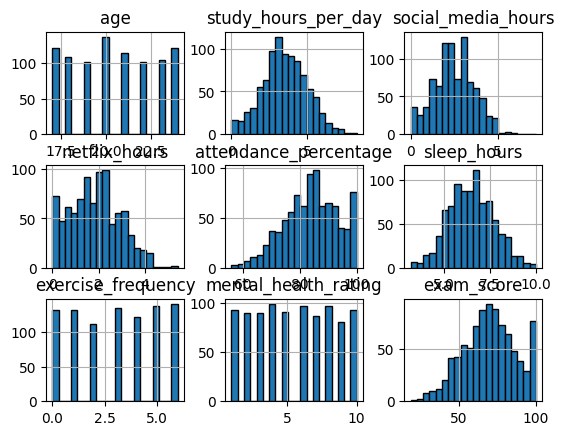

In [16]:
df.hist(bins =20 , edgecolor="black")
plt.show()

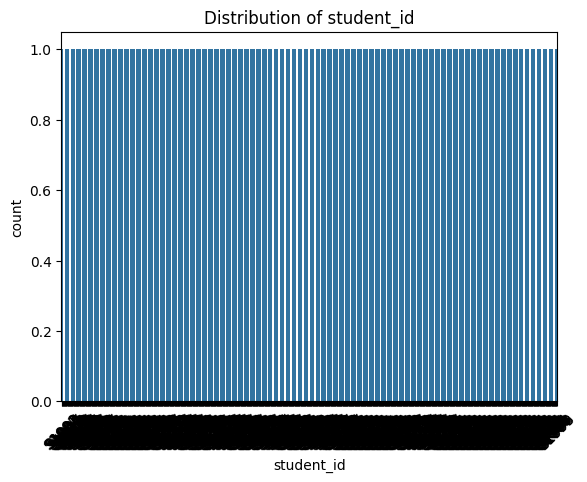

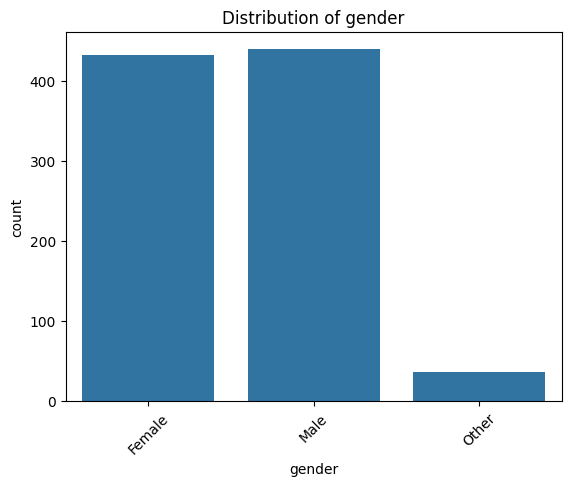

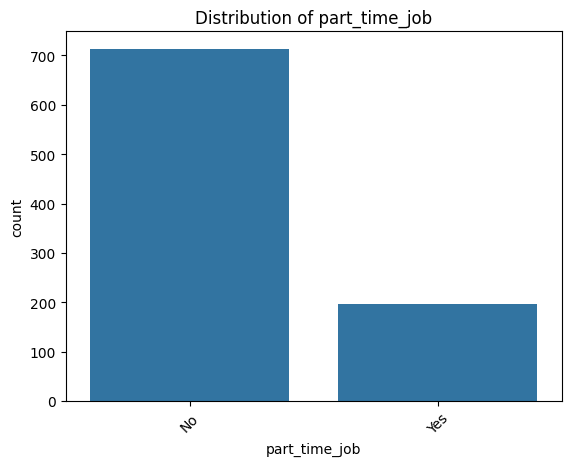

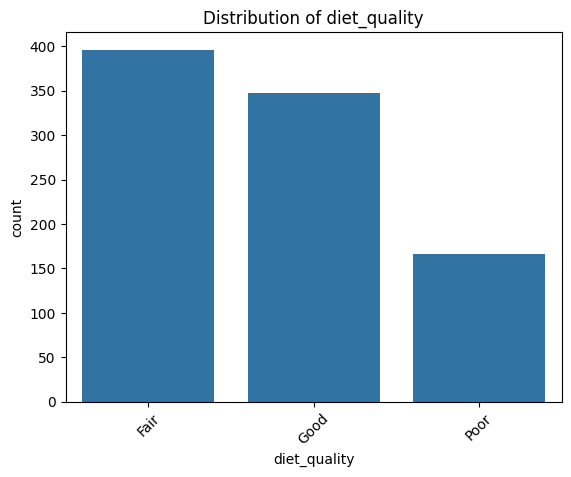

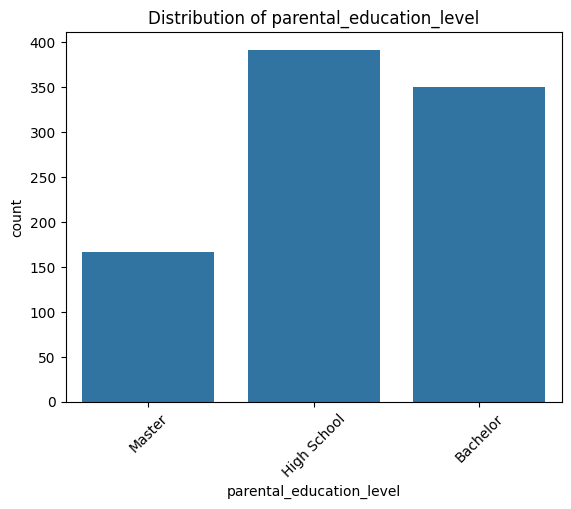

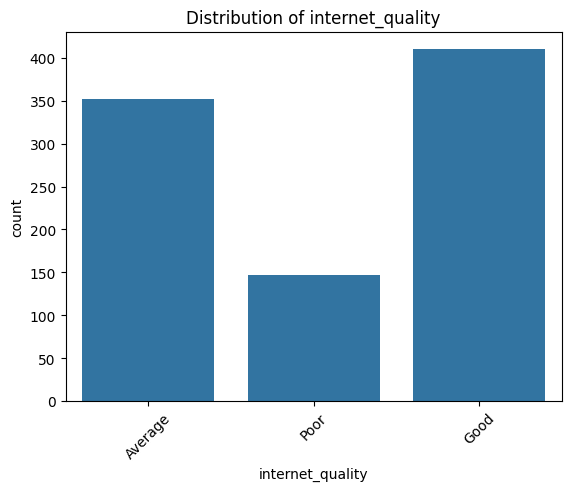

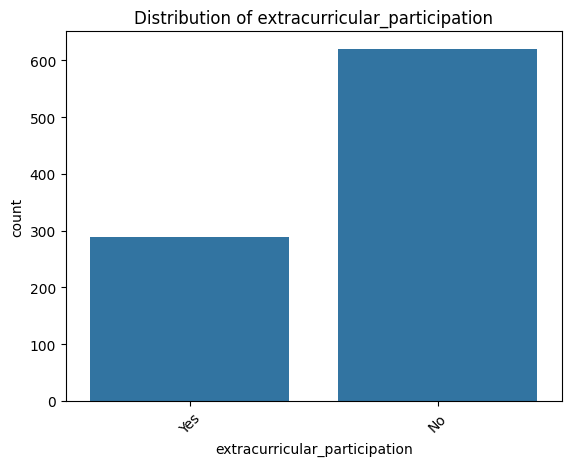

In [17]:
for col in categorical_cols:
    sns.countplot(data =df , x = col)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation =45)
    plt.show()

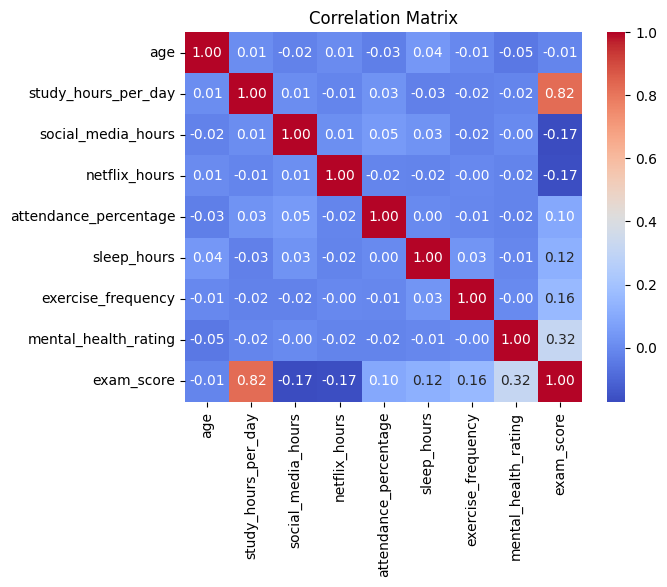

In [18]:
sns.heatmap(df.corr(numeric_only = True), annot = True, cmap = "coolwarm" , fmt =".2f")
plt.title("Correlation Matrix")
plt.show()

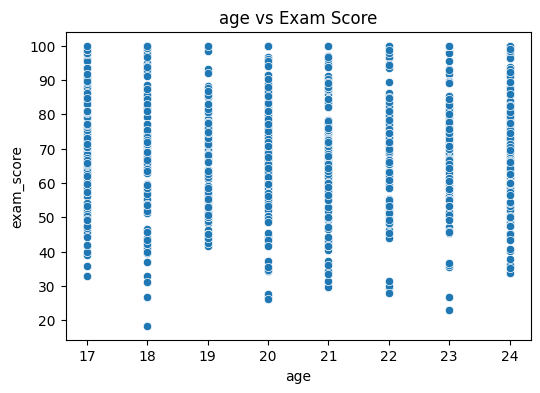

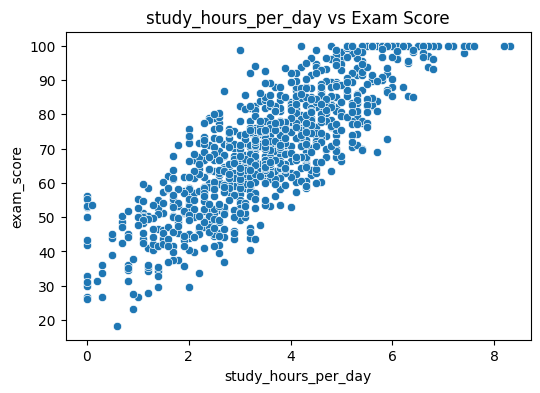

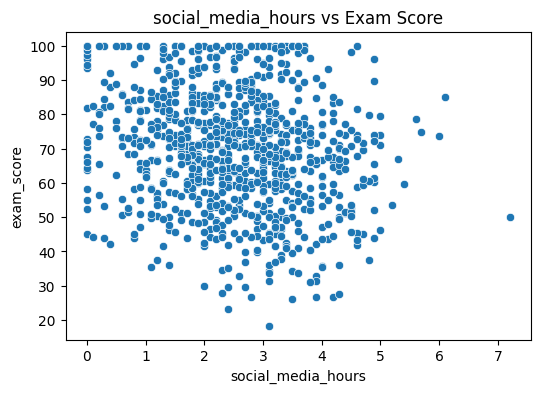

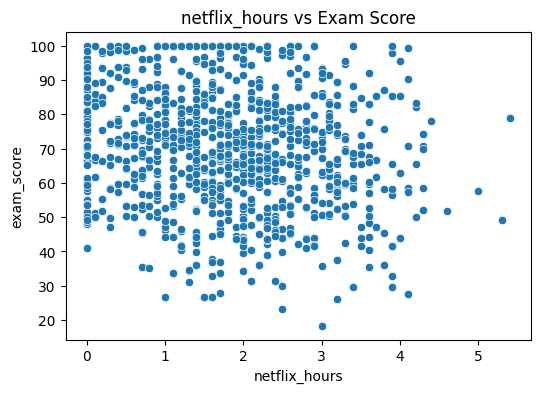

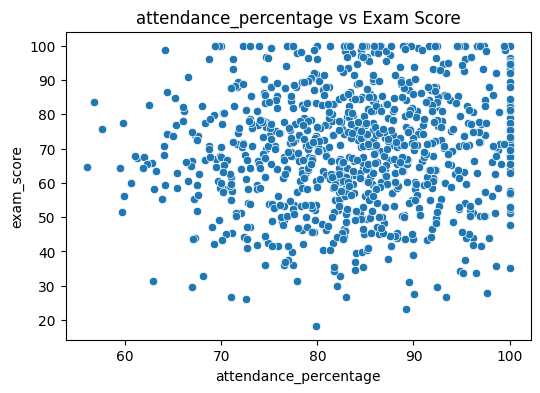

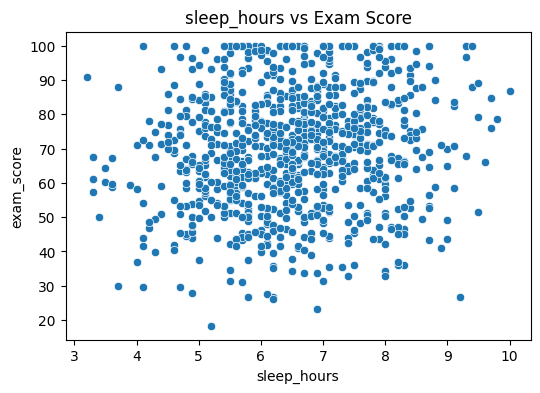

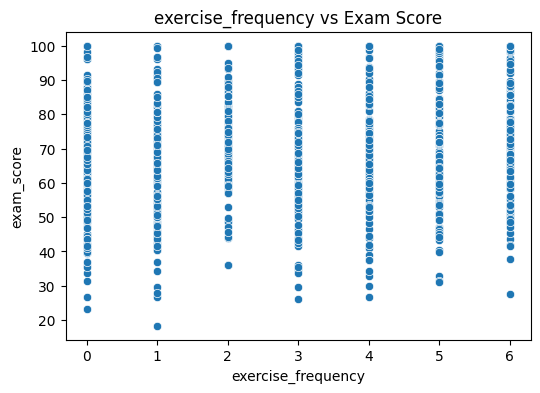

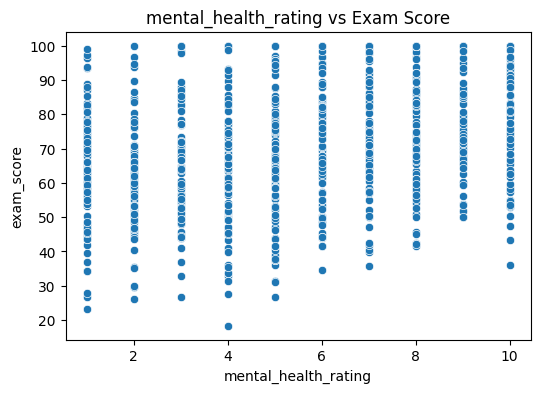

In [19]:
num_features =['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating']
for feature in num_features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data = df , x=feature , y ="exam_score")
    plt.title(f"{feature} vs Exam Score")

In [20]:

df.describe().columns

Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating', 'exam_score'],
      dtype='object')

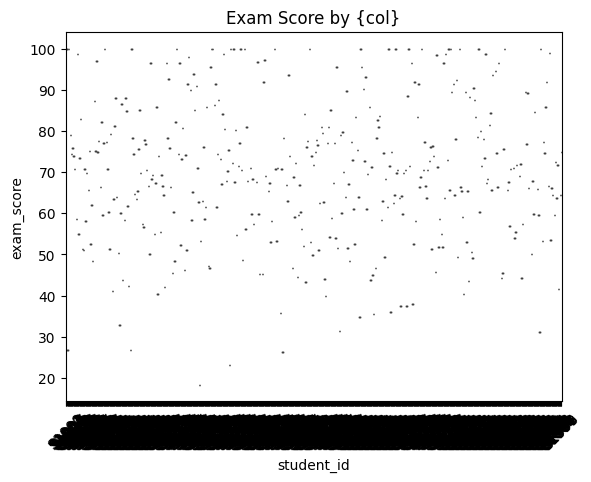

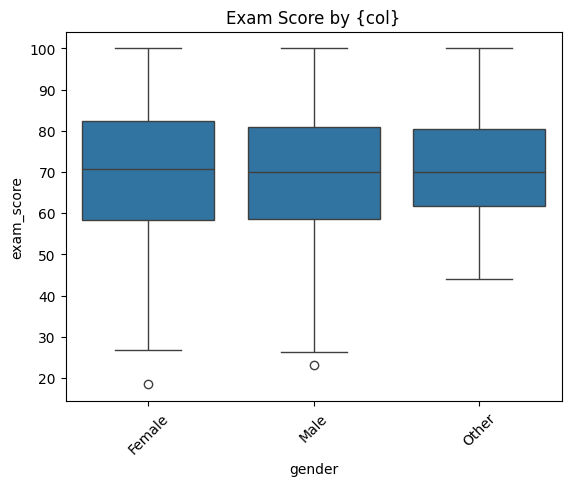

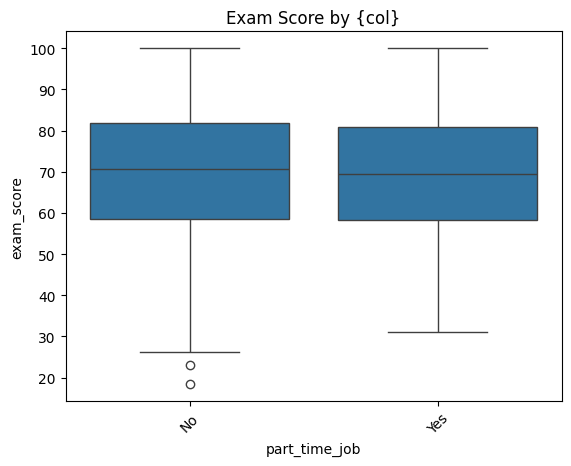

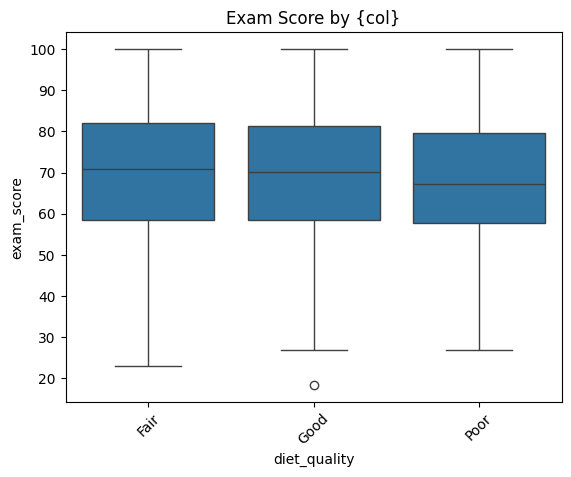

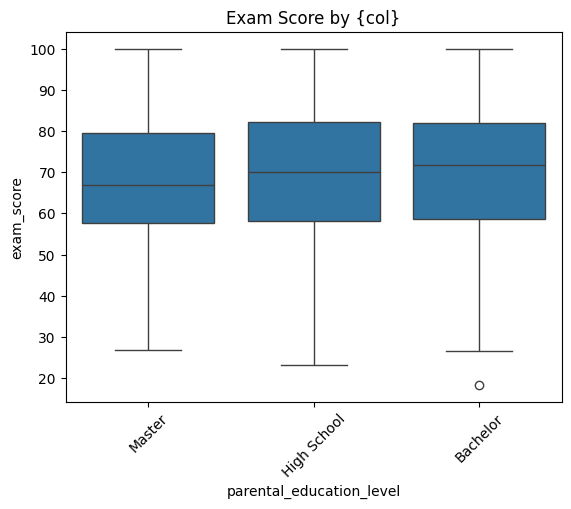

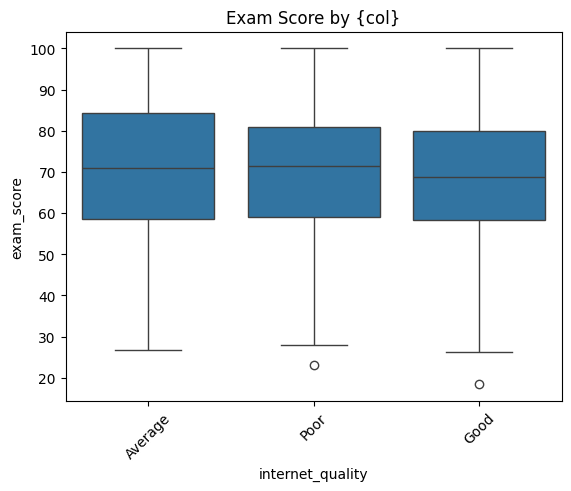

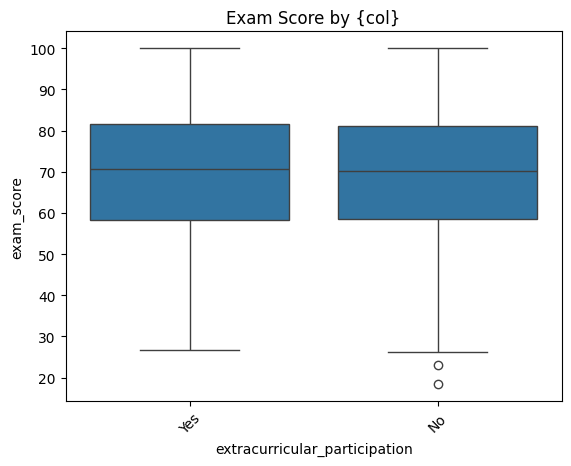

In [21]:
for col in categorical_cols:
    sns.boxplot(data =df , x=col , y="exam_score")
    plt.title("Exam Score by {col}")
    plt.xticks(rotation = 45)
    plt.show()

In [22]:
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error , r2_score
from sklearn.linear_model import LinearRegression , Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor



In [23]:
df.columns


Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='object')

In [24]:
df.head(2)

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0


In [25]:
features = [ 'study_hours_per_day' ,  'attendance_percentage' ,'mental_health_rating','part_time_job' ,'sleep_hours' ]
target ="exam_score"


In [26]:
df_model = df[features + [target]].copy()

df_model

In [27]:
df_model

,study_hours_per_day,attendance_percentage,mental_health_rating,part_time_job,sleep_hours,exam_score
0,0.0,85.0,8,No,8.0,56.2
1,6.9,97.3,8,No,4.6,100.0
2,1.4,94.8,1,No,8.0,34.3
3,1.0,71.0,1,No,9.2,26.8
4,5.0,90.9,1,No,4.9,66.4
...,...,...,...,...,...,...
995,2.6,77.0,6,No,7.5,76.1
996,2.9,86.0,6,Yes,6.8,65.9
997,3.0,61.9,9,No,6.5,64.4
998,5.4,100.0,1,Yes,7.6,69.7


In [28]:
le = LabelEncoder()

In [29]:
df_model["part_time_job"] = le.fit_transform(df_model["part_time_job"])

In [30]:
df_model

,study_hours_per_day,attendance_percentage,mental_health_rating,part_time_job,sleep_hours,exam_score
0,0.0,85.0,8,0,8.0,56.2
1,6.9,97.3,8,0,4.6,100.0
2,1.4,94.8,1,0,8.0,34.3
3,1.0,71.0,1,0,9.2,26.8
4,5.0,90.9,1,0,4.9,66.4
...,...,...,...,...,...,...
995,2.6,77.0,6,0,7.5,76.1
996,2.9,86.0,6,1,6.8,65.9
997,3.0,61.9,9,0,6.5,64.4
998,5.4,100.0,1,1,7.6,69.7


In [31]:
X = df_model[features]
y= df_model[target]

In [32]:
X_train , X_test ,y_train , y_test  = train_test_split(X,y,test_size =0.2)

In [33]:
models ={ 
    "LinearRegression":{
            "model": LinearRegression(),
            "params":{}
    },
    "DecisionTree" :{
             "model" : DecisionTreeRegressor(),
            "params":{"max_depth":[3,5,10], "min_samples_split":[2,5]}
},
    "RandomForest" :{
              "model": RandomForestRegressor(),
              "params":{"n_estimators": [50,100] , "max_depth" : [5,10]}
          }
}
          

In [34]:
best_models =[]

In [35]:
for name , config in models.items():
    print(f"Training {name}")
    grid = GridSearchCV(config["model"],config["params"],cv=5,scoring = "neg_mean_squared_error")
    grid.fit(X_train , y_train)
    y_pred = grid.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test , y_pred))
    r2 = r2_score(y_test , y_pred)
    best_models.append({
        "model":name,
        "best_params": grid.best_params_,
        "rmse":rmse,
        "r2": r2
    })


    

Training LinearRegression
Training DecisionTree
Training RandomForest


In [36]:
best_models

[{'model': 'LinearRegression',
  'best_params': {},
  'rmse': np.float64(7.308046605953199),
  'r2': 0.8130735689067321},
 {'model': 'DecisionTree',
  'best_params': {'max_depth': 5, 'min_samples_split': 2},
  'rmse': np.float64(7.841894415688735),
  'r2': 0.7847663955250379},
 {'model': 'RandomForest',
  'best_params': {'max_depth': 5, 'n_estimators': 50},
  'rmse': np.float64(7.413026702845247),
  'r2': 0.8076645992856619}]

In [37]:
results_df = pd.DataFrame(best_models)

In [38]:
results_df.sort_values(by ="rmse")

,model,best_params,rmse,r2
0,LinearRegression,{},7.308047,0.813074
2,RandomForest,"{'max_depth': 5, 'n_estimators': 50}",7.413027,0.807665
1,DecisionTree,"{'max_depth': 5, 'min_samples_split': 2}",7.841894,0.784766


In [39]:
import joblib

In [40]:
best_row = results_df.sort_values(by="rmse").iloc[0]

In [41]:
best_row

model          LinearRegression
best_params                  {}
rmse                   7.308047
r2                     0.813074
Name: 0, dtype: object

In [42]:
best_model_name= best_row["model"]

In [43]:
best_model_config = models[best_model_name]

In [44]:
best_model_config

{'model': LinearRegression(), 'params': {}}

In [45]:
final_model = best_model_config["model"]

In [46]:
final_model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [47]:
final_model.predict(X_test)

array([ 80.46594508,  68.38334944,  74.3087117 ,  91.52584331,
        62.39081909,  81.73266078,  53.00815757,  98.07031515,
        63.08783432, 122.57020293,  69.58524171,  76.48969124,
        93.68221401,  44.07954472,  60.18318046,  54.27941821,
        97.56842667,  86.38678834,  55.7323605 ,  73.32456053,
        67.37855373,  75.7404905 ,  48.2945095 ,  74.83885426,
        67.04794846,  76.60690732,  69.35389946,  60.9230965 ,
        85.31042026,  78.4898864 ,  78.33524881,  63.09414629,
        79.98469099,  47.70223942,  46.89711801,  48.86907863,
        72.24230521,  60.91996362,  81.14151653,  40.85472813,
        78.93711347,  85.15391158,  47.41966756,  81.39667248,
        56.25121079,  80.37605908,  96.41397838,  62.84795641,
        97.86319106,  72.00500419,  80.36926071,  54.04532213,
        93.42130856,  85.05701304,  55.72437836,  51.45722985,
        61.10861881,  59.80546684,  66.36405947,  74.89289694,
        70.40477667,  62.09636584,  83.47702877,  77.00

In [48]:
joblib.dump(final_model , "best_model.pkl")

['best_model.pkl']

In [49]:
joblib.load("best_model.pkl").predict(X_test)

array([ 80.46594508,  68.38334944,  74.3087117 ,  91.52584331,
        62.39081909,  81.73266078,  53.00815757,  98.07031515,
        63.08783432, 122.57020293,  69.58524171,  76.48969124,
        93.68221401,  44.07954472,  60.18318046,  54.27941821,
        97.56842667,  86.38678834,  55.7323605 ,  73.32456053,
        67.37855373,  75.7404905 ,  48.2945095 ,  74.83885426,
        67.04794846,  76.60690732,  69.35389946,  60.9230965 ,
        85.31042026,  78.4898864 ,  78.33524881,  63.09414629,
        79.98469099,  47.70223942,  46.89711801,  48.86907863,
        72.24230521,  60.91996362,  81.14151653,  40.85472813,
        78.93711347,  85.15391158,  47.41966756,  81.39667248,
        56.25121079,  80.37605908,  96.41397838,  62.84795641,
        97.86319106,  72.00500419,  80.36926071,  54.04532213,
        93.42130856,  85.05701304,  55.72437836,  51.45722985,
        61.10861881,  59.80546684,  66.36405947,  74.89289694,
        70.40477667,  62.09636584,  83.47702877,  77.00